In [1]:
from pathlib import Path

DATASET_PATH = Path("/kaggle/input")

for item in DATASET_PATH.iterdir():
    print(item)

/kaggle/input/datasets


In [2]:
from pathlib import Path

DATASET_DIR = Path("/kaggle/input/datasets")

for item in DATASET_DIR.iterdir():
    print(item)

/kaggle/input/datasets/dhawalsrivastava2583


In [3]:
from pathlib import Path

DATASET_DIR = Path("/kaggle/input/datasets/dhawalsrivastava2583")

for item in DATASET_DIR.iterdir():
    print(item)
    

/kaggle/input/datasets/dhawalsrivastava2583/flood-classification-dataset


In [4]:
from pathlib import Path

DATASET_DIR = Path("/kaggle/input/datasets/dhawalsrivastava2583/flood-classification-dataset")

for item in DATASET_DIR.iterdir():
    print(item)

/kaggle/input/datasets/dhawalsrivastava2583/flood-classification-dataset/Dataset


In [5]:
from pathlib import Path

DATASET_DIR = Path("/kaggle/input/datasets/dhawalsrivastava2583/flood-classification-dataset/Dataset")

for item in DATASET_DIR.iterdir():
    print(item)

/kaggle/input/datasets/dhawalsrivastava2583/flood-classification-dataset/Dataset/Non Flood Images
/kaggle/input/datasets/dhawalsrivastava2583/flood-classification-dataset/Dataset/Flood Images
/kaggle/input/datasets/dhawalsrivastava2583/flood-classification-dataset/Dataset/Annotation


In [6]:
from pathlib import Path

DATASET_DIR = Path("/kaggle/input/datasets/dhawalsrivastava2583/flood-classification-dataset/Dataset")

classes = ["Non Flood Images", "Flood Images"]

for class_name in classes:
    folder = DATASET_DIR / class_name
    images = list(folder.glob("*"))
    print(class_name, ":", len(images))

Non Flood Images : 3748
Flood Images : 9296


In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATASET_DIR = Path("/kaggle/input/datasets/dhawalsrivastava2583/flood-classification-dataset/Dataset")

image_paths = []
labels = []

for class_name in ["Non Flood Images", "Flood Images"]:
    folder = DATASET_DIR / class_name
    for image_file in folder.glob("*"):
        image_paths.append(str(image_file))
        labels.append(class_name)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print(df.head())
print(df.shape)
print(df["label"].value_counts())

                                          image_path             label
0  /kaggle/input/datasets/dhawalsrivastava2583/fl...  Non Flood Images
1  /kaggle/input/datasets/dhawalsrivastava2583/fl...  Non Flood Images
2  /kaggle/input/datasets/dhawalsrivastava2583/fl...  Non Flood Images
3  /kaggle/input/datasets/dhawalsrivastava2583/fl...  Non Flood Images
4  /kaggle/input/datasets/dhawalsrivastava2583/fl...  Non Flood Images
(13044, 2)
label
Flood Images        9296
Non Flood Images    3748
Name: count, dtype: int64


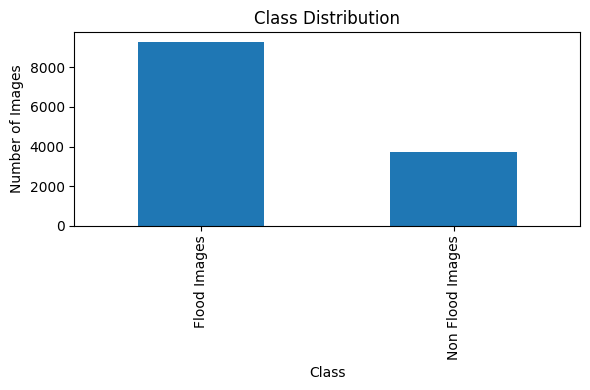

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df["label"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

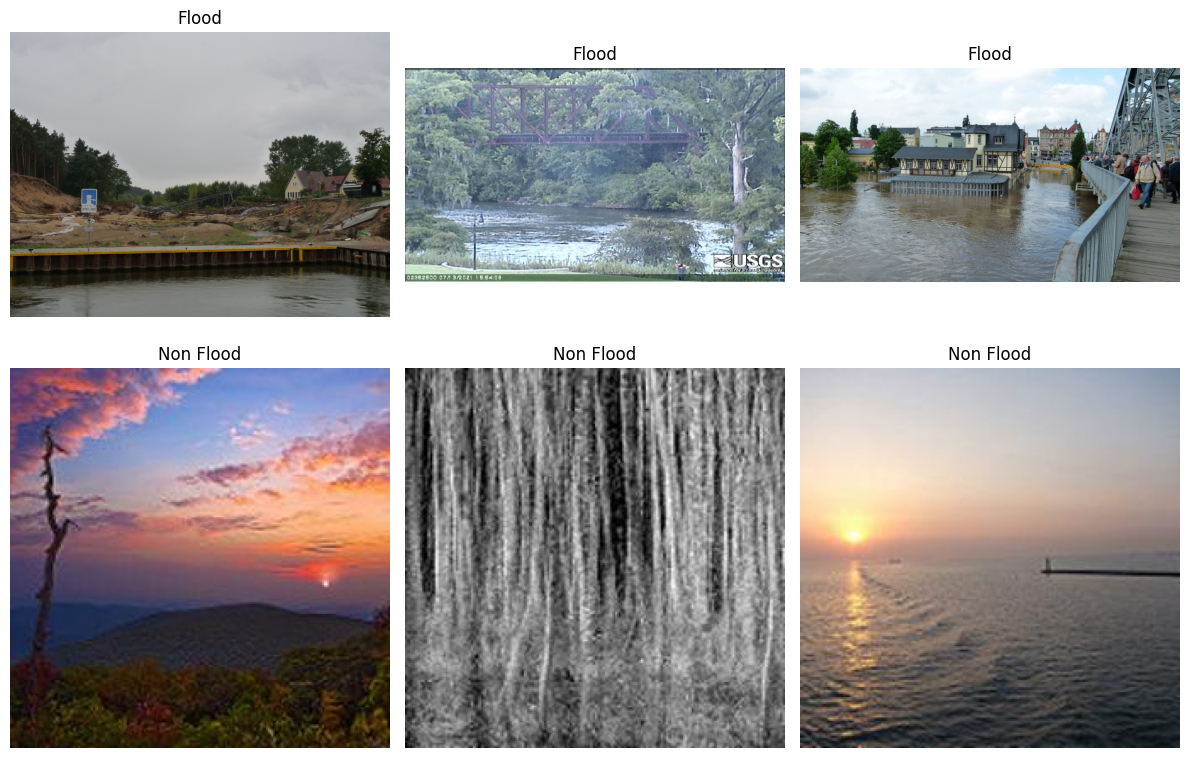

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import random

flood_folder = DATASET_DIR / "Flood Images"
non_flood_folder = DATASET_DIR / "Non Flood Images"

flood_images = list(flood_folder.glob("*"))
non_flood_images = list(non_flood_folder.glob("*"))

plt.figure(figsize=(12,8))

for i in range(3):
    img = Image.open(random.choice(flood_images))

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title("Flood")
    plt.axis("off")

for i in range(3):
    img = Image.open(random.choice(non_flood_images))

    plt.subplot(2,3,i+4)
    plt.imshow(img)
    plt.title("Non Flood")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

df["label_index"] = df["label"].map({
    "Non Flood Images": 0,
    "Flood Images": 1
})

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label_index"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_index"],
    random_state=42
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))

print("\nTraining class count:")
print(train_df["label"].value_counts())

print("\nValidation class count:")
print(val_df["label"].value_counts())

print("\nTesting class count:")
print(test_df["label"].value_counts())

Training images: 9130
Validation images: 1957
Testing images: 1957

Training class count:
label
Flood Images        6507
Non Flood Images    2623
Name: count, dtype: int64

Validation class count:
label
Flood Images        1395
Non Flood Images     562
Name: count, dtype: int64

Testing class count:
label
Flood Images        1394
Non Flood Images     563
Name: count, dtype: int64


In [12]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["image_path"].values, train_df["label_index"].values)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df["image_path"].values, val_df["label_index"].values)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df["image_path"].values, test_df["label_index"].values)
)

train_ds = train_ds.map(load_image).shuffle(1000).batch(BATCH_SIZE)
val_ds = val_ds.map(load_image).batch(BATCH_SIZE)
test_ds = test_ds.map(load_image).batch(BATCH_SIZE)

print("Train, validation, and test datasets created successfully")

Train, validation, and test datasets created successfully


In [13]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

print("Data augmentation layer created successfully")

Data augmentation layer created successfully


In [14]:
from tensorflow.keras import models, layers

cnn_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(2, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
EPOCHS = 10

history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10


I0000 00:00:1781813342.317971     168 cuda_dnn.cc:529] Loaded cuDNN version 91002


286/286 ━━━━━━━━━━━━━━━━━━━━ 149s 453ms/step - accuracy: 0.8317 - loss: 0.4310 - val_accuracy: 0.9392 - val_loss: 0.1877
Epoch 2/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 82s 261ms/step - accuracy: 0.8862 - loss: 0.2797 - val_accuracy: 0.9607 - val_loss: 0.1032
Epoch 3/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 81s 257ms/step - accuracy: 0.9170 - loss: 0.2083 - val_accuracy: 0.9796 - val_loss: 0.0572
Epoch 4/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 82s 263ms/step - accuracy: 0.9364 - loss: 0.1668 - val_accuracy: 0.9785 - val_loss: 0.0554
Epoch 5/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 96s 308ms/step - accuracy: 0.9467 - loss: 0.1384 - val_accuracy: 0.9264 - val_loss: 0.2411
Epoch 6/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 87s 279ms/step - accuracy: 0.9609 - loss: 0.1059 - val_accuracy: 0.8508 - val_loss: 0.7804
Epoch 7/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 88s 280ms/step - accuracy: 0.9645 - loss: 0.0974 - val_accuracy: 0.8835 - val_loss: 0.3614
Epoch 8/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 89s 285ms/step - accuracy: 0.9679 - loss: 0.0834 - va

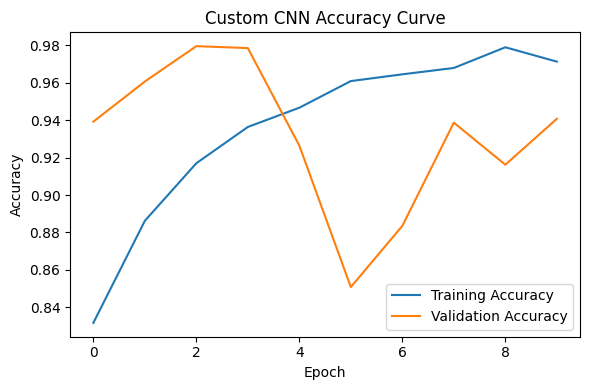

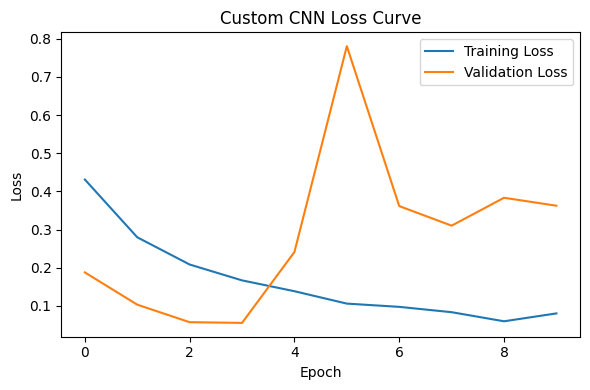

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Custom CNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Custom CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
test_loss, test_accuracy = cnn_model.evaluate(test_ds)

print("Custom CNN Test Loss:", test_loss)
print("Custom CNN Test Accuracy:", test_accuracy)

62/62 ━━━━━━━━━━━━━━━━━━━━ 21s 342ms/step - accuracy: 0.9448 - loss: 0.3168
Custom CNN Test Loss: 0.3167813718318939
Custom CNN Test Accuracy: 0.9448134899139404


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step

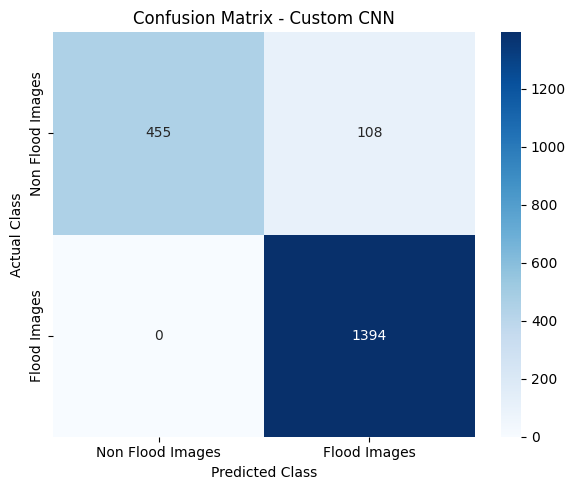

                  precision    recall  f1-score   support

Non Flood Images       1.00      0.81      0.89       563
    Flood Images       0.93      1.00      0.96      1394

        accuracy                           0.94      1957
       macro avg       0.96      0.90      0.93      1957
    weighted avg       0.95      0.94      0.94      1957



In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = cnn_model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

class_names = ["Non Flood Images", "Flood Images"]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Custom CNN")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

In [19]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import models, layers

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

mobilenet_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu"),
    layers.Dense(2, activation="softmax")
])

mobilenet_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 96s 290ms/step - accuracy: 0.9683 - loss: 0.0894 - val_accuracy: 0.9990 - val_loss: 0.0061
Epoch 2/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 83s 265ms/step - accuracy: 0.9855 - loss: 0.0431 - val_accuracy: 0.9995 - val_loss: 0.0020
Epoch 3/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 103s 335ms/step - accuracy: 0.9863 - loss: 0.0414 - val_accuracy: 0.9959 - val_loss: 0.0175
Epoch 4/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 82s 261ms/step - accuracy: 0.9890 - loss: 0.0324 - val_accuracy: 0.9980 - val_loss: 0.0074
Epoch 5/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 82s 260ms/step - accuracy: 0.9890 - loss: 0.0296 - val_accuracy: 0.9980 - val_loss: 0.0063
Epoch 6/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 83s 265ms/step - accuracy: 0.9917 - loss: 0.0243 - val_accuracy: 0.9980 - val_loss: 0.0042
Epoch 7/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 81s 259ms/step - accuracy: 0.9915 - loss: 0.0237 - val_accuracy: 0.9980 - val_loss: 0.0055
Epoch 8/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 84s 267ms/step - accuracy: 0.9898 - loss: 

In [21]:
mobilenet_test_loss, mobilenet_test_accuracy = mobilenet_model.evaluate(test_ds)

print("MobileNetV2 Test Loss:", mobilenet_test_loss)
print("MobileNetV2 Test Accuracy:", mobilenet_test_accuracy)

62/62 ━━━━━━━━━━━━━━━━━━━━ 12s 196ms/step - accuracy: 0.9939 - loss: 0.0179
MobileNetV2 Test Loss: 0.01789575256407261
MobileNetV2 Test Accuracy: 0.9938681721687317


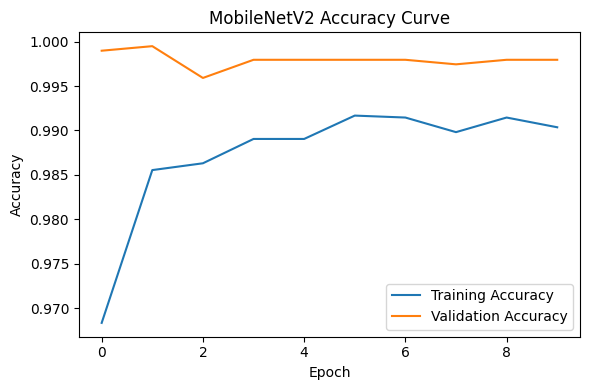

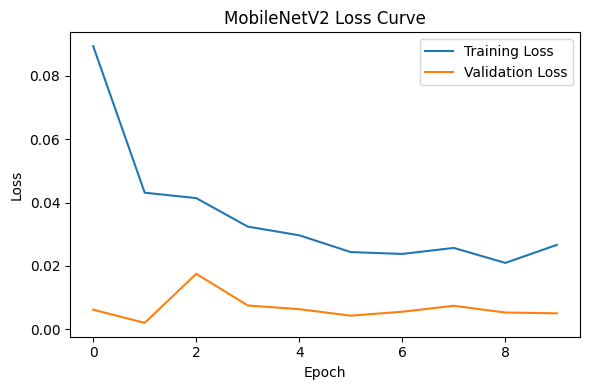

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(mobilenet_history.history["accuracy"], label="Training Accuracy")
plt.plot(mobilenet_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("MobileNetV2 Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(mobilenet_history.history["loss"], label="Training Loss")
plt.plot(mobilenet_history.history["val_loss"], label="Validation Loss")
plt.title("MobileNetV2 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

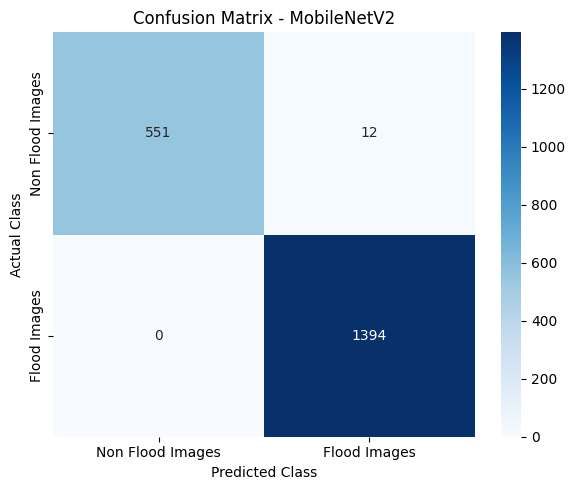

                  precision    recall  f1-score   support

Non Flood Images       1.00      0.98      0.99       563
    Flood Images       0.99      1.00      1.00      1394

        accuracy                           0.99      1957
       macro avg       1.00      0.99      0.99      1957
    weighted avg       0.99      0.99      0.99      1957



In [23]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_true_mobile = []
y_pred_mobile = []

for images, labels in test_ds:
    predictions = mobilenet_model.predict(images)
    y_true_mobile.extend(labels.numpy())
    y_pred_mobile.extend(np.argmax(predictions, axis=1))

class_names = ["Non Flood Images", "Flood Images"]

cm_mobile = confusion_matrix(y_true_mobile, y_pred_mobile)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_mobile,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - MobileNetV2")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

print(classification_report(y_true_mobile, y_pred_mobile, target_names=class_names))

In [24]:
mobilenet_model.save("Flood_MobileNetV2_Model.keras")

print("Model saved successfully")

Model saved successfully
